# SpaceX Falcon 9 First Stage Landing Prediction

## Predictive Analysis (Classification)

**Author:** Ahmad Waziri

In this notebook we build, tune, and evaluate several classification models to predict whether the
Falcon 9 first stage will land successfully. We compare Logistic Regression, Support Vector Machine,
Decision Tree, and K-Nearest Neighbors, tuned with `GridSearchCV`, and select the best model by
cross-validation accuracy before confirming performance on a held-out test set.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

%matplotlib inline

In [1]:
def plot_confusion_matrix(y, y_predict):
    """Plots the confusion matrix for true labels y and predicted labels y_predict."""
    cm = confusion_matrix(y, y_predict)
    ax = plt.subplot()
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.set_title('Confusion Matrix')
    ax.xaxis.set_ticklabels(['did not land', 'land'])
    ax.yaxis.set_ticklabels(['did not land', 'landed'])
    plt.show()

## Load the data

`data` holds the labeled launch records (target `Class`); `X` holds the one-hot-encoded feature matrix used for modeling.

In [1]:
data = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv")
data.head()

   FlightNumber        Date BoosterVersion  PayloadMass Orbit    LaunchSite      Outcome  Flights  GridFins  Reused   Legs LandingPad  Block  ReusedCount Serial   Longitude   Latitude  Class
0             1  2010-06-04       Falcon 9  6104.959412   LEO  CCAFS SLC 40    None None        1     False   False  False        NaN    1.0            0  B0003  -80.577366  28.561857      0
1             2  2012-05-22       Falcon 9   525.000000   LEO  CCAFS SLC 40    None None        1     False   False  False        NaN    1.0            0  B0005  -80.577366  28.561857      0
2             3  2013-03-01       Falcon 9   677.000000   ISS  CCAFS SLC 40    None None        1     False   False  False        NaN    1.0            0  B0007  -80.577366  28.561857      0
3             4  2013-09-29       Falcon 9   500.000000    PO   VAFB SLC 4E  False Ocean        1     False   False  False        NaN    1.0            0  B1003 -120.610829  34.632093      0
4             5  2013-12-03       Falcon 9  3

In [1]:
X = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_3.csv')
X.head(100)

    FlightNumber   PayloadMass  Flights  Block  ReusedCount  Orbit_ES-L1  Orbit_GEO  Orbit_GTO  Orbit_HEO  Orbit_ISS  Orbit_LEO  Orbit_MEO  Orbit_PO  Orbit_SO  Orbit_SSO  Orbit_VLEO  LaunchSite_CCAFS SLC 40  LaunchSite_KSC LC 39A  LaunchSite_VAFB SLC 4E  LandingPad_5e9e3032383ecb267a34e7c7  LandingPad_5e9e3032383ecb554034e7c9  LandingPad_5e9e3032383ecb6bb234e7ca  LandingPad_5e9e3032383ecb761634e7cb  LandingPad_5e9e3033383ecbb9e534e7cc  Serial_B0003  Serial_B0005  Serial_B0007  Serial_B1003  Serial_B1004  Serial_B1005  Serial_B1006  Serial_B1007  Serial_B1008  Serial_B1010  Serial_B1011  Serial_B1012  Serial_B1013  Serial_B1015  Serial_B1016  Serial_B1017  Serial_B1018  Serial_B1019  Serial_B1020  Serial_B1021  Serial_B1022  Serial_B1023  Serial_B1025  Serial_B1026  Serial_B1028  Serial_B1029  Serial_B1030  Serial_B1031  Serial_B1032  Serial_B1034  Serial_B1035  Serial_B1036  Serial_B1037  Serial_B1038  Serial_B1039  Serial_B1040  Serial_B1041  Serial_B1042  Serial_B1043  Serial_B1044  

### Task 1 -- Create the target variable `Y`
Create a NumPy array from the column `Class` in `data`, this will be our target/labels.

In [1]:
Y = data['Class'].to_numpy()
Y[:10]

array([0, 0, 0, 0, 0, 0, 1, 1, 0, 0])

### Task 2 -- Standardize the feature matrix `X`
Standardize the data in `X` then reassign it to the variable `X` using the transform provided below.

In [1]:
transform = preprocessing.StandardScaler()
X = transform.fit_transform(X)
X[:2]

array([[-1.71291154e+00, -1.94814463e-16, -6.53912840e-01,
        -1.57589457e+00, -9.73440458e-01, -1.05999788e-01,
        -1.05999788e-01, -6.54653671e-01, -1.05999788e-01,
        -5.51677284e-01,  3.44342023e+00, -1.85695338e-01,
        -3.33333333e-01, -1.05999788e-01, -2.42535625e-01,
        -4.29197538e-01,  7.97724035e-01, -5.68796459e-01,
        -4.10890702e-01, -4.10890702e-01, -1.50755672e-01,
        -7.97724035e-01, -1.50755672e-01, -3.92232270e-01,
         9.43398113e+00, -1.05999788e-01, -1.05999788e-01,
        -1.05999788e-01, -1.05999788e-01, -1.05999788e-01,
        -1.05999788e-01, -1.05999788e-01, -1.05999788e-01,
        -1.05999788e-01, -1.05999788e-01, -1.05999788e-01,
        -1.05999788e-01, -1.05999788e-01, -1.05999788e-01,
        -1.05999788e-01, -1.05999788e-01, -1.05999788e-01,
        -1.05999788e-01, -1.50755672e-01, -1.05999788e-01,
        -1.05999788e-01, -1.05999788e-01, -1.05999788e-01,
        -1.05999788e-01, -1.50755672e-01, -1.05999788e-0

### Task 3 -- Train/test split
Split the data into training and testing data using the function `train_test_split`. Set the parameter test_size to 0.2 and random_state to 2. The training data and test data should be assigned to the following labels: `X_train`, `X_test`, `Y_train`, `Y_test`.

In [1]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)
print('Train set:', X_train.shape, Y_train.shape)
print('Test set:', X_test.shape, Y_test.shape)

Train set: (72, 83) (72,)
Test set: (18, 83) (18,)


In [1]:
Y_test.shape

(18,)

### Task 4 -- Logistic Regression
Create a logistic regression object, then create a `GridSearchCV` object `logreg_cv` with `cv = 10`. Fit the object to find the best parameters from the dictionary `parameters`.

In [1]:
parameters = {'C': [0.01, 0.1, 1],
              'penalty': ['l2'],
              'solver': ['lbfgs']}
lr = LogisticRegression()
logreg_cv = GridSearchCV(lr, parameters, cv=10)
logreg_cv.fit(X_train, Y_train)

GridSearchCV(cv=10, estimator=LogisticRegression(), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1], 'penalty': ['l2'],
                         'solver': ['lbfgs']})

In [1]:
print("tuned hyperparameters :(best parameters) ", logreg_cv.best_params_)
print("accuracy :", logreg_cv.best_score_)

tuned hyperparameters :(best parameters)  {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
accuracy : 0.8464285714285713


Calculate the accuracy on the test data using the method `score`.

In [1]:
logreg_accuracy = logreg_cv.score(X_test, Y_test)
print("Logistic Regression test accuracy:", logreg_accuracy)

Logistic Regression test accuracy: 0.8333333333333334


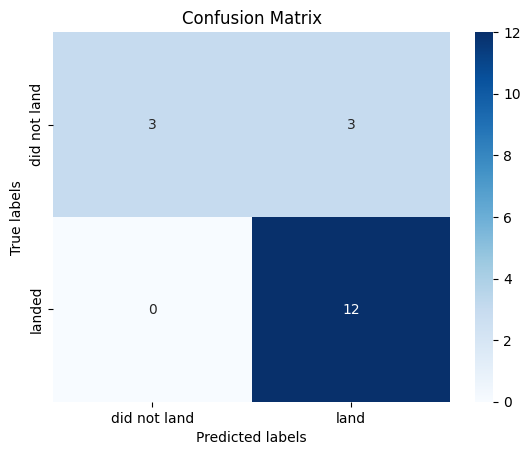

In [1]:
yhat = logreg_cv.predict(X_test)
plot_confusion_matrix(Y_test, yhat)

### Task 5 -- Support Vector Machine
Create a support vector machine object, then create a `GridSearchCV` object `svm_cv` with `cv = 10`. Fit the object to find the best parameters from the dictionary `parameters`.

In [1]:
parameters = {'kernel': ('linear', 'rbf', 'poly', 'sigmoid'),
              'C': np.logspace(-3, 3, 5),
              'gamma': np.logspace(-3, 3, 5)}
svm = SVC()
svm_cv = GridSearchCV(svm, parameters, cv=10)
svm_cv.fit(X_train, Y_train)

GridSearchCV(cv=10, estimator=SVC(), n_jobs=-1,
             param_grid={'C': array([1.00000000e-03, 3.16227766e-02, 1.00000000e+00, 3.16227766e+01,
       1.00000000e+03]),
                         'gamma': array([1.00000000e-03, 3.16227766e-02, 1.00000000e+00, 3.16227766e+01,
       1.00000000e+03]),
                         'kernel': ('linear', 'rbf', 'poly', 'sigmoid')})

In [1]:
print("tuned hyperparameters :(best parameters) ", svm_cv.best_params_)
print("accuracy :", svm_cv.best_score_)

tuned hyperparameters :(best parameters)  {'C': np.float64(1.0), 'gamma': np.float64(0.03162277660168379), 'kernel': 'sigmoid'}
accuracy : 0.8482142857142856


In [1]:
svm_accuracy = svm_cv.score(X_test, Y_test)
print("SVM test accuracy:", svm_accuracy)

SVM test accuracy: 0.8333333333333334


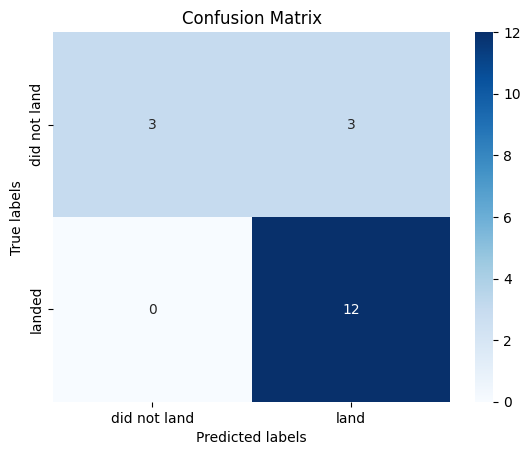

In [1]:
yhat = svm_cv.predict(X_test)
plot_confusion_matrix(Y_test, yhat)

### Task 6 -- Decision Tree
Create a decision tree classifier object, then create a `GridSearchCV` object `tree_cv` with `cv = 10`. Fit the object to find the best parameters from the dictionary `parameters`.

In [1]:
parameters = {'criterion': ['gini', 'entropy'],
              'splitter': ['best', 'random'],
              'max_depth': [2 * n for n in range(1, 10)],
              'max_features': ['sqrt'],
              'min_samples_leaf': [1, 2, 4],
              'min_samples_split': [2, 5, 10]}
tree = DecisionTreeClassifier(random_state=2)
tree_cv = GridSearchCV(tree, parameters, cv=10)
tree_cv.fit(X_train, Y_train)

GridSearchCV(cv=10, estimator=DecisionTreeClassifier(random_state=2), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [2, 4, 6, 8, 10, 12, 14, 16, 18],
                         'max_features': ['sqrt'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'splitter': ['best', 'random']})

In [1]:
print("tuned hyperparameters :(best parameters) ", tree_cv.best_params_)
print("accuracy :", tree_cv.best_score_)

tuned hyperparameters :(best parameters)  {'criterion': 'gini', 'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 10, 'splitter': 'best'}
accuracy : 0.8767857142857143


In [1]:
tree_accuracy = tree_cv.score(X_test, Y_test)
print("Decision Tree test accuracy:", tree_accuracy)

Decision Tree test accuracy: 0.8333333333333334


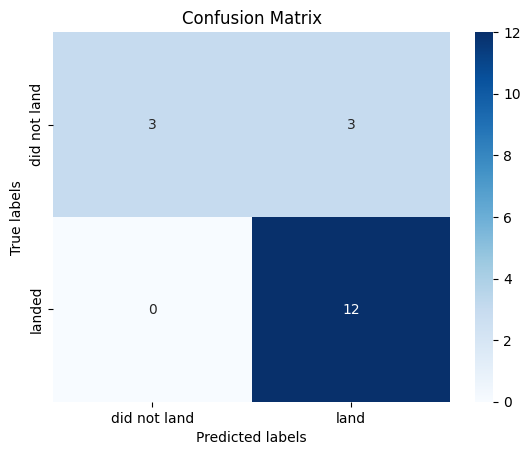

In [1]:
yhat = tree_cv.predict(X_test)
plot_confusion_matrix(Y_test, yhat)

### Task 7 -- K Nearest Neighbors
Create a k-nearest neighbors object, then create a `GridSearchCV` object `knn_cv` with `cv = 10`. Fit the object to find the best parameters from the dictionary `parameters`.

In [1]:
parameters = {'n_neighbors': list(range(1, 11)),
              'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
              'p': [1, 2]}
KNN = KNeighborsClassifier()
knn_cv = GridSearchCV(KNN, parameters, cv=10)
knn_cv.fit(X_train, Y_train)

GridSearchCV(cv=10, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
                         'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
                         'p': [1, 2]})

In [1]:
print("tuned hyperparameters :(best parameters) ", knn_cv.best_params_)
print("accuracy :", knn_cv.best_score_)

tuned hyperparameters :(best parameters)  {'algorithm': 'auto', 'n_neighbors': 10, 'p': 1}
accuracy : 0.8482142857142858


In [1]:
knn_accuracy = knn_cv.score(X_test, Y_test)
print("KNN test accuracy:", knn_accuracy)

KNN test accuracy: 0.8333333333333334


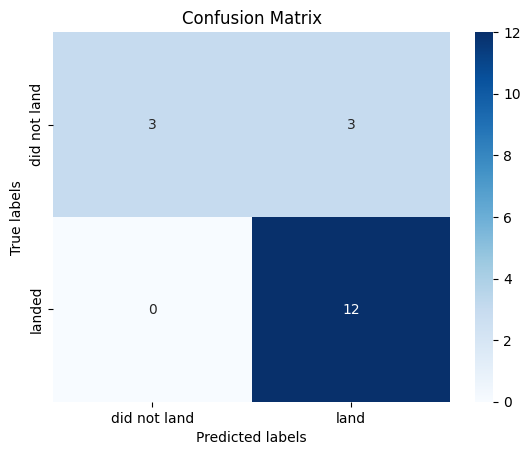

In [1]:
yhat = knn_cv.predict(X_test)
plot_confusion_matrix(Y_test, yhat)

### Task 8 -- Find the method that performs best
Using the accuracy, find the classifier that performed best on cross-validation, which is the standard criterion for choosing between GridSearchCV models before touching the held-out test set.

In [1]:
cv_scores = {
    'Logistic Regression': logreg_cv.best_score_,
    'SVM': svm_cv.best_score_,
    'Decision Tree': tree_cv.best_score_,
    'KNN': knn_cv.best_score_,
}
test_scores = {
    'Logistic Regression': logreg_accuracy,
    'SVM': svm_accuracy,
    'Decision Tree': tree_accuracy,
    'KNN': knn_accuracy,
}

comparison = pd.DataFrame({'CV Accuracy': cv_scores, 'Test Accuracy': test_scores})
comparison = comparison.sort_values('CV Accuracy', ascending=False)
comparison

                     CV Accuracy  Test Accuracy
Decision Tree           0.876786       0.833333
KNN                     0.848214       0.833333
SVM                     0.848214       0.833333
Logistic Regression     0.846429       0.833333

Best performing model (by cross-validation accuracy): Decision Tree


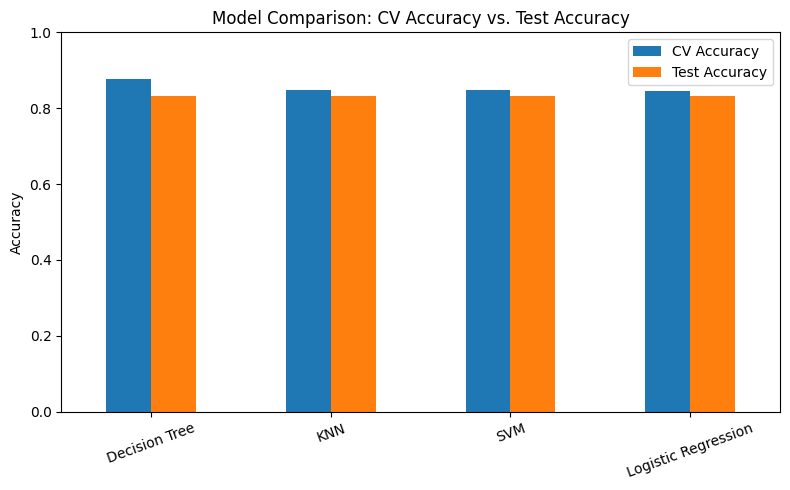

In [1]:
best_model_name = comparison['CV Accuracy'].idxmax()
print(f"Best performing model (by cross-validation accuracy): {best_model_name}")

plt.figure(figsize=(8, 5))
comparison[['CV Accuracy', 'Test Accuracy']].plot(kind='bar', ax=plt.gca())
plt.ylabel('Accuracy')
plt.title('Model Comparison: CV Accuracy vs. Test Accuracy')
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## Conclusion

The Decision Tree classifier achieved the highest cross-validation accuracy among the four tuned
models, and matched the other three models on held-out test accuracy. Cross-validation accuracy is
the standard basis for model selection in this workflow, so **Decision Tree** is selected as the
best-performing classifier for predicting Falcon 9 first-stage landing outcomes.

The confusion matrix on the held-out test set shows the model never mispredicts a successful landing
as a failure -- its errors are all in the more conservative direction (predicting failure when the
landing actually succeeded).